In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Replacing blank values with 0 as tenure is zero and no total charges are recorded

In [6]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum().sum()


np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
df["customerID"].duplicated().sum()   

np.int64(0)

In [15]:
def conv(value):
    if value==1:
        return "Yes"
    else:
        return "No"
    value=conv(df["SeniorCitizen"])
df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)
df["SeniorCitizen"].value_counts()


SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

Converted 0 and 1 values of SeniorCitizen to Yes/No to make it easier to understand

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


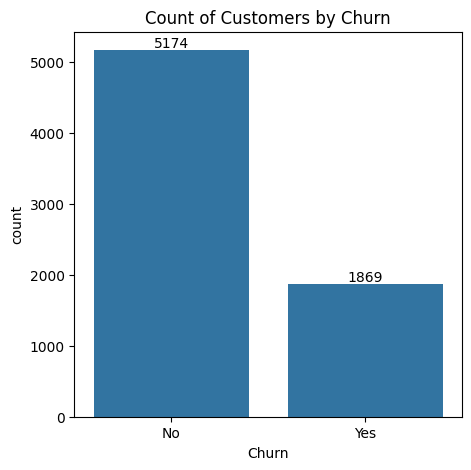

In [50]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x="Churn",data=df)
ax.set_title("Count of Customers by Churn")
ax.bar_label(ax.containers[0])
plt.show()

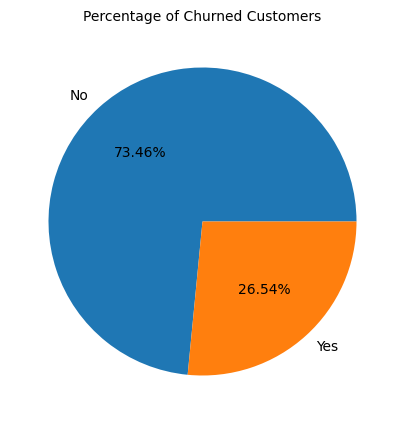

In [40]:
plt.figure(figsize=(5,5))
gb=df.groupby("Churn").agg({"Churn": "count"})
plt.pie(gb["Churn"],labels=gb.index,autopct="%1.2f%%")
plt.title("Percentage of Churned Customers",fontsize=10)
plt.show()

From the above pie chart we can conclude that 26.54% of our customers have churned out.
Now let's explore the reason behind this

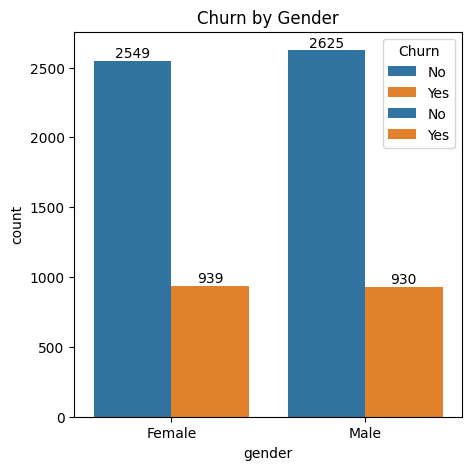

In [92]:
plt.figure(figsize=(5,5))
sns.countplot(x="gender", data=df,hue="Churn")
ax = sns.countplot(x="gender", data=df,hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn by Gender")
plt.show()

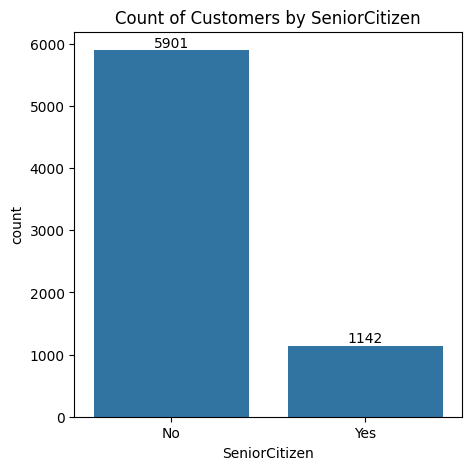

In [60]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x="SeniorCitizen", data=df)
plt.bar_label(ax.containers[0])
plt.title("Count of Customers by SeniorCitizen")
plt.show()

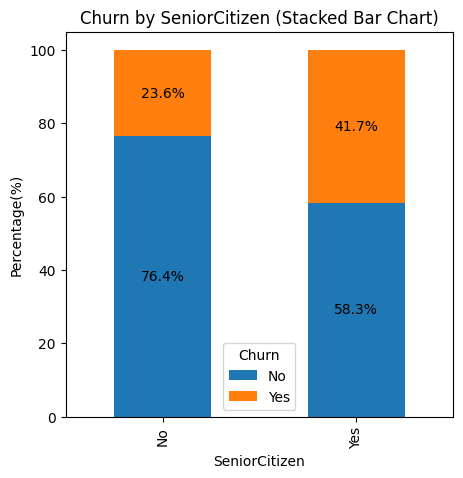

In [63]:
grp = df.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)
grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100

ax = grp_pct.plot(kind='bar', stacked=True, figsize=(5,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%1.1f%%', label_type='center')

plt.title("Churn by SeniorCitizen (Stacked Bar Chart)")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage(%)")
plt.legend(title="Churn")
plt.show()
plt.show()

Comparitvely a greater percentage of people in senior citizen category have churned 

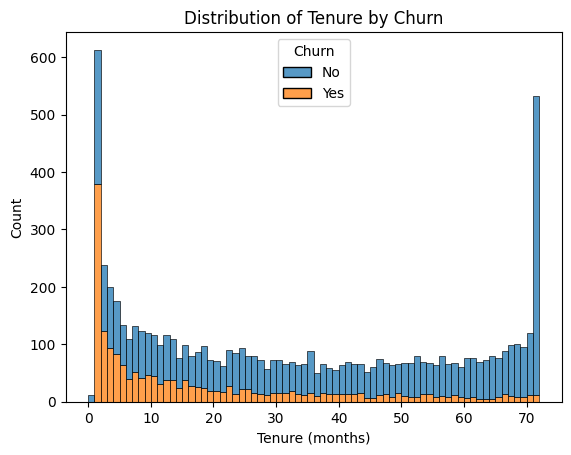

In [68]:
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=72)
plt.title("Distribution of Tenure by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

People who have used our services for a long time have stayed and people who have used our services 1 or 2 months have churned.

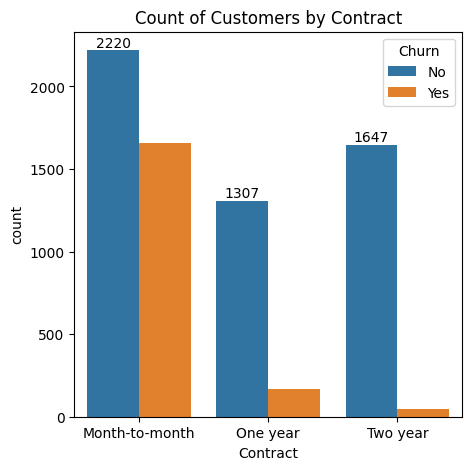

In [70]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x="Contract", hue="Churn", data=df)
plt.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

People who have Month-to-month contract are likely to churn from then those who have 1 or 2 years of contract

In [72]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

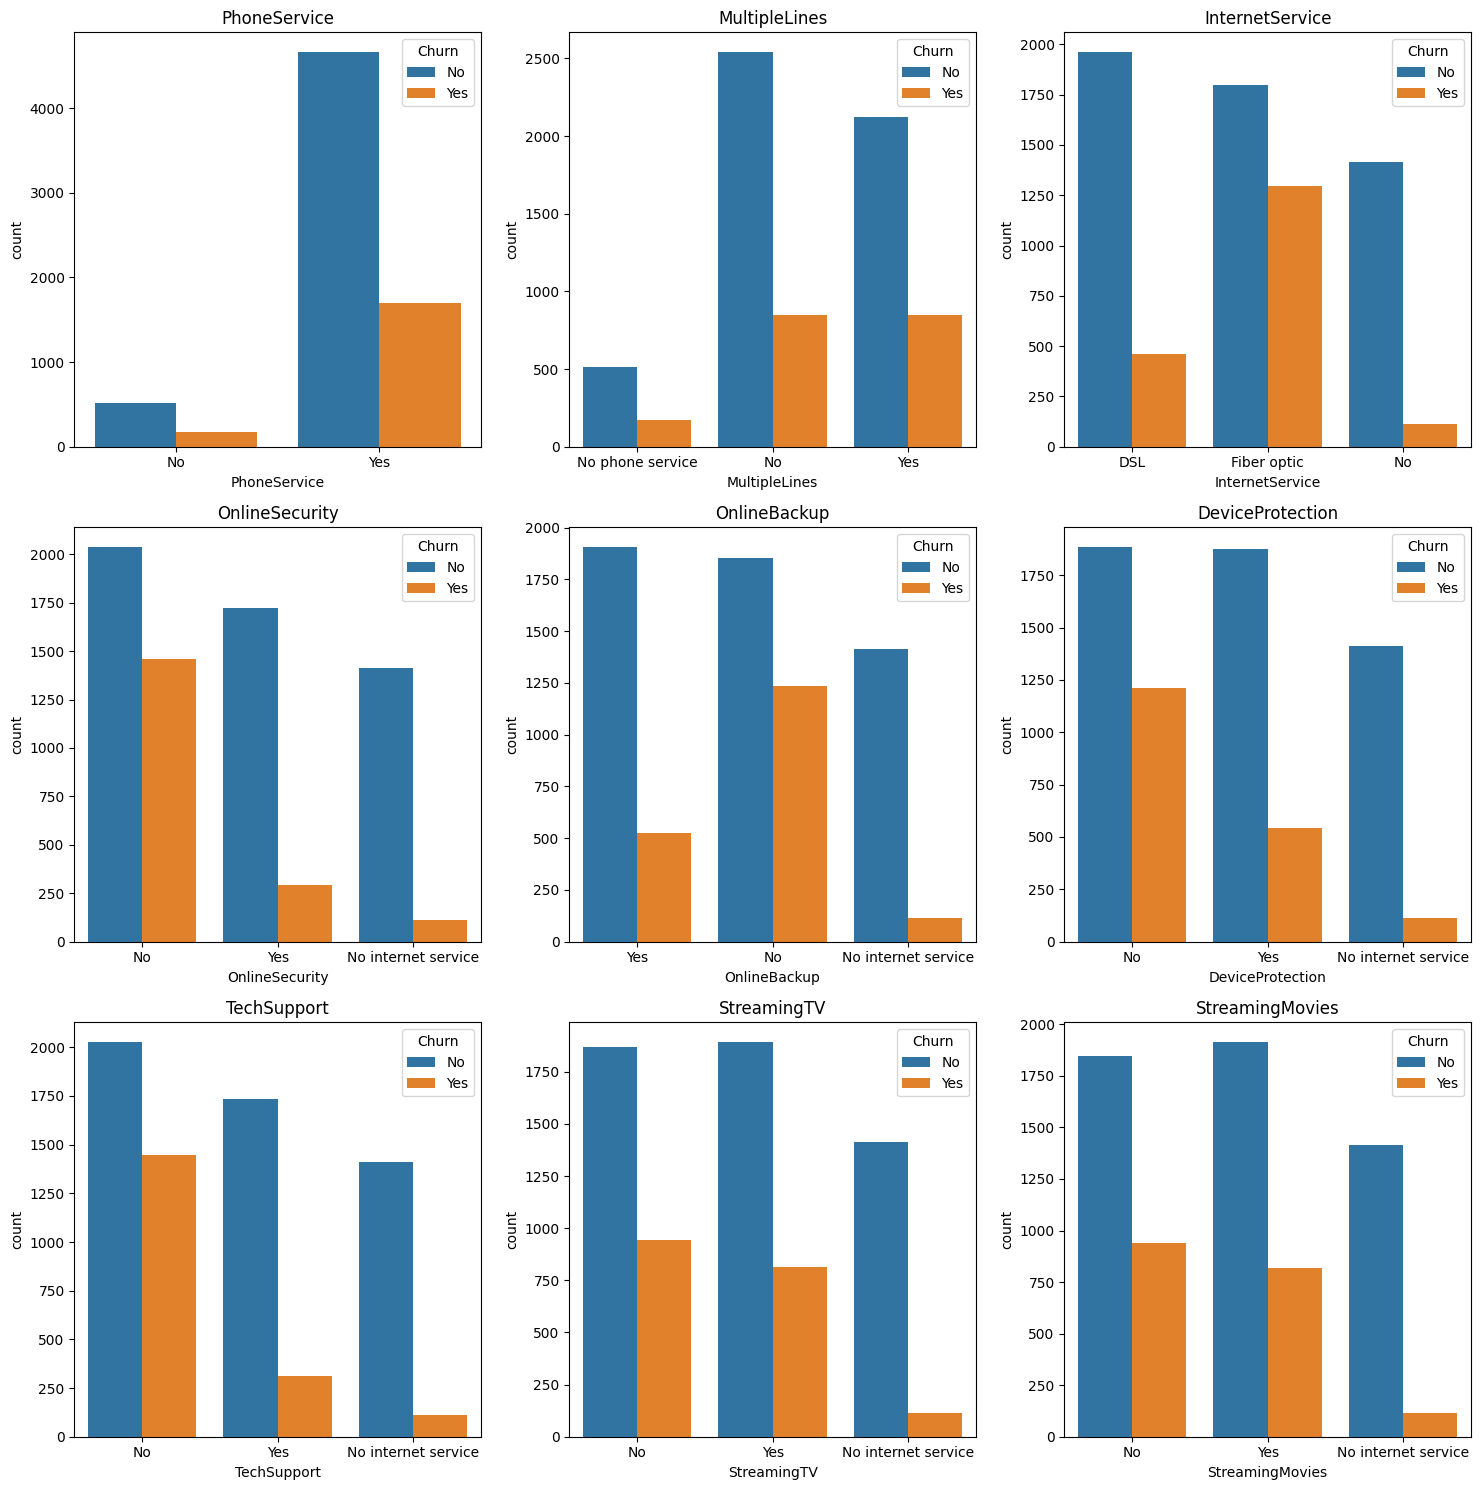

In [83]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df,x=col,ax=axes[i],hue="Churn")
    axes[i].set_title(cols[i])

plt.tight_layout()
plt.show()

Customers without Online Security, Online Backup, Device Protection, and Tech Support have significantly higher churn rates than those who use these services.

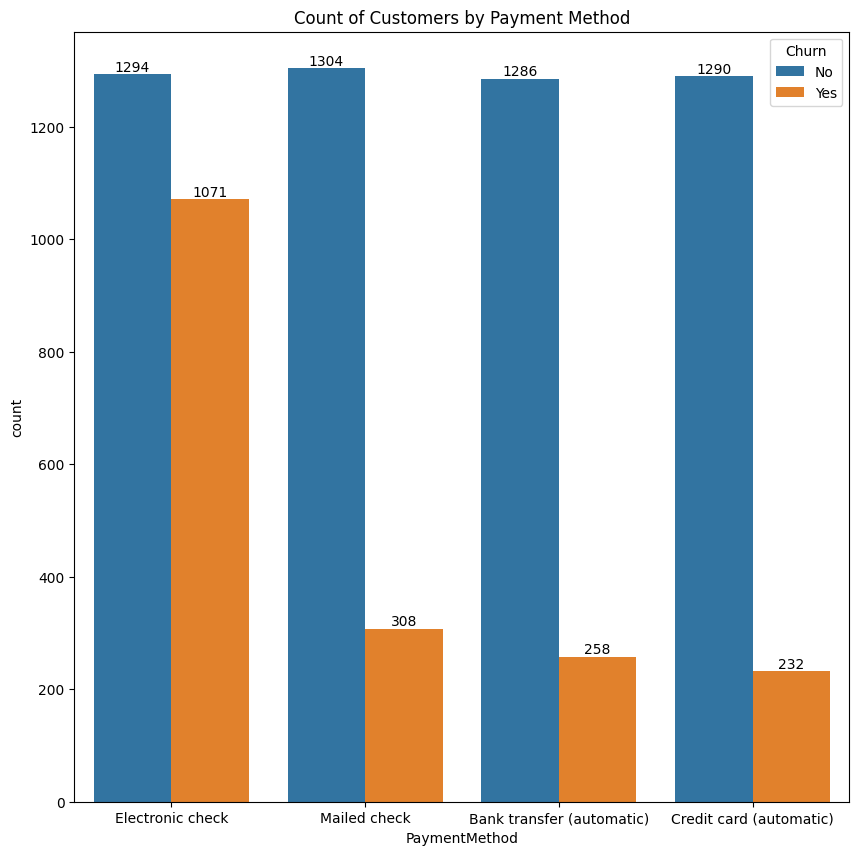

In [89]:
plt.figure(figsize=(10,10))
ax = sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.title("Count of Customers by Payment Method")
plt.show()

Customer is likely to churn when he is using electronic check as a payment method